Paper Link : https://www.mdpi.com/2076-3417/15/17/9555

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, models, transforms
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

In [3]:
DATA_DIR = '/content/drive/MyDrive/Datasets/FinalDataset'

NUM_CLASSES = 6

BATCH_SIZE = 32
LEARNING_RATE = 1e-4 # 0.0001
NUM_EPOCHS = 100
VAL_SPLIT = 0.20 # 20% for validation, 80% for training


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

# Data augmentation for training (Section 3.5)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),       # Resize (after MTCNN)
    # transforms.RandomHorizontalFlip(),   # Random horizontal flipping
    # transforms.RandomRotation(15),       # Random rotation (up to 15 degrees)
    # transforms.ColorJitter(brightness=0.2, contrast=0.2), # Brightness/contrast
    transforms.ToTensor(),
    normalize,
])

In [5]:
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    normalize,
])

In [6]:
try:
    dataset_for_train = datasets.ImageFolder(DATA_DIR, transform=train_transform)
    dataset_for_val = datasets.ImageFolder(DATA_DIR, transform=val_transform)
except FileNotFoundError:
    print(f"Error: Dataset directory not found at: {DATA_DIR}")
    print(f"Please set DATA_DIR to the folder containing your class subfolders (e.g., 'angry', 'happy').")
    exit()

In [7]:
targets = dataset_for_train.targets
class_names = dataset_for_train.classes
print(f"Found {len(class_names)} classes: {class_names}")

if len(class_names) != NUM_CLASSES:
    print(f"Warning: Code is set for {NUM_CLASSES} classes, but dataset found {len(class_names)}.")
    print("Proceeding, but check if NUM_CLASSES is correct.")
    NUM_CLASSES = len(class_names) # Auto-adjust to what's found

Found 6 classes: ['Natural', 'anger', 'fear', 'joy', 'sadness', 'surprise']


In [8]:
indices = list(range(len(targets)))

# Split indices into train and validation sets (80/20)
train_indices, val_indices = train_test_split(
    indices,
    test_size=VAL_SPLIT,
    random_state=42,  # For reproducibility
    stratify=targets  # Ensures 80/20 split for EACH class
)
print(f"Total images: {len(targets)}")
print(f"Training images: {len(train_indices)}")
print(f"Validation images: {len(val_indices)}")


Total images: 4218
Training images: 3374
Validation images: 844


In [9]:

# Create the Subset objects
train_dataset = Subset(dataset_for_train, train_indices)
val_dataset = Subset(dataset_for_val, val_indices)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [10]:
# --- 3. Model Architecture (The "Proposed Fusion Model" from Section 3.4) ---
# --- (UPDATED to be compatible with older torchvision versions) ---

class FusionModel(nn.Module):
    def __init__(self, num_classes=6, freeze_backbones=True): # Default set to 6
        super(FusionModel, self).__init__()

        # 1. Backbone 1: ResNet50
        # --- Using pretrained=True for backward compatibility ---
        self.resnet = models.resnet50(pretrained=True)
        self.resnet.fc = nn.Identity() # Remove final layer

        # 2. Backbone 2: EfficientNetB0
        # --- Using pretrained=True for backward compatibility ---
        self.efficientnet = models.efficientnet_b0(pretrained=True)
        self.efficientnet.classifier = nn.Identity() # Remove final layer

        if freeze_backbones:
            for param in self.resnet.parameters():
                param.requires_grad = False
            for param in self.efficientnet.parameters():
                param.requires_grad = False

        # 3. Fusion Block (Sec 3.4)
        self.fusion_block = nn.Sequential(
            nn.Linear(2048 + 1280, 1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.5)
        )

        # 4. Final Classifier
        self.classifier = nn.Linear(512, num_classes) # num_classes will be 6

    def forward(self, x):
        features_resnet = self.resnet(x)
        features_efficientnet = self.efficientnet(x)

        features_combined = torch.cat((features_resnet, features_efficientnet), dim=1)

        x = self.fusion_block(features_combined)
        output = self.classifier(x)

        return output

In [11]:
model = FusionModel(num_classes=NUM_CLASSES).to(device)

# --- 4. Training Setup (from Paper Section 3.5) ---

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 215MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 158MB/s]


In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
import torch
import numpy as np

print("Starting training...")

# Lists to store history for plotting
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

# --- Variables to track the Best Model ---
best_val_acc = 0.0
best_epoch_info = {}

for epoch in range(NUM_EPOCHS):

    # ==========================
    #      Training Phase
    # ==========================
    model.train()
    running_loss = 0.0
    running_corrects = 0
    train_labels_all = []
    train_preds_all = []

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

        train_labels_all.extend(labels.cpu().numpy())
        train_preds_all.extend(preds.cpu().numpy())

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_corrects.double() / len(train_dataset)

    # Store training history
    history['train_loss'].append(epoch_loss)
    history['train_acc'].append(epoch_acc.cpu().numpy())

    # ==========================
    #     Validation Phase
    # ==========================
    model.eval()
    val_running_loss = 0.0
    val_running_corrects = 0
    val_labels_all = []
    val_preds_all = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)
            val_running_loss += loss.item() * inputs.size(0)
            val_running_corrects += torch.sum(preds == labels.data)

            val_labels_all.extend(labels.cpu().numpy())
            val_preds_all.extend(preds.cpu().numpy())

    val_epoch_loss = val_running_loss / len(val_dataset)
    val_epoch_acc = val_running_corrects.double() / len(val_dataset)

    # Store validation history
    history['val_loss'].append(val_epoch_loss)
    history['val_acc'].append(val_epoch_acc.cpu().numpy())

    # --- Generate Class-wise Report ---
    # classification_report computes precision, recall, f1 for EACH class
    val_class_report = classification_report(
        val_labels_all,
        val_preds_all,
        zero_division=0,
        digits=4 # Ensure 4 decimal places
        # target_names=['Class A', 'Class B'] # Optional: Add your actual class names here
    )

    # --- Check if this is the Best Model ---
    # We use validation accuracy to determine the best model
    if val_epoch_acc > best_val_acc:
        best_val_acc = val_epoch_acc
        # Save all info about this epoch
        best_epoch_info = {
            'epoch': epoch + 1,
            'val_loss': val_epoch_loss,
            'val_acc': val_epoch_acc,
            'report': val_class_report
        }

    # --- Print Current Epoch Stats ---
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print(f"  Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f}")
    print(f"  Val Loss:   {val_epoch_loss:.4f} | Val Acc:   {val_epoch_acc:.4f}")
    print("\n  --- Class-wise Metrics (Validation) ---")
    print(val_class_report)
    print("-" * 80)

# ==========================
#    Final Summary
# ==========================
print("\n" + "="*40)
print("      TRAINING COMPLETE       ")
print("="*40)
print(f"Best Validation Accuracy was found at Epoch {best_epoch_info['epoch']}")
print(f"Best Val Acc:  {best_epoch_info['val_acc']:.4f}")
print(f"Best Val Loss: {best_epoch_info['val_loss']:.4f}")
print("\n--- Best Model Class-wise Performance ---")
print(best_epoch_info['report'])

Starting training...
Epoch 1/100
  Train Loss: 1.3481 | Train Acc: 0.5608
  Val Loss:   1.2357 | Val Acc:   0.5640

  --- Class-wise Metrics (Validation) ---
              precision    recall  f1-score   support

           0     1.0000    0.0096    0.0190       104
           1     0.0000    0.0000    0.0000        90
           2     0.0000    0.0000    0.0000        28
           3     0.5635    1.0000    0.7208       475
           4     0.0000    0.0000    0.0000        91
           5     0.0000    0.0000    0.0000        56

    accuracy                         0.5640       844
   macro avg     0.2606    0.1683    0.1233       844
weighted avg     0.4403    0.5640    0.4080       844

--------------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch 2/100
  Train Loss: 1.1763 | Train Acc: 0.5868
  Val Loss:   1.0736 | Val Acc:   0.6149

  --- Class-wise Metrics (Validation) ---
              precision    recall  f1-score   support

           0     0.4351    0.5481    0.4851       104
           1     0.0000    0.0000    0.0000        90
           2     0.0000    0.0000    0.0000        28
           3     0.6501    0.9663    0.7773       475
           4     0.4286    0.0330    0.0612        91
           5     0.0000    0.0000    0.0000        56

    accuracy                         0.6149       844
   macro avg     0.2523    0.2579    0.2206       844
weighted avg     0.4657    0.6149    0.5038       844

--------------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch 3/100
  Train Loss: 1.0454 | Train Acc: 0.6357
  Val Loss:   1.0299 | Val Acc:   0.6244

  --- Class-wise Metrics (Validation) ---
              precision    recall  f1-score   support

           0     0.5714    0.3462    0.4311       104
           1     0.4231    0.1222    0.1897        90
           2     0.0000    0.0000    0.0000        28
           3     0.6422    0.9937    0.7802       475
           4     0.4000    0.0879    0.1441        91
           5     0.0000    0.0000    0.0000        56

    accuracy                         0.6244       844
   macro avg     0.3394    0.2583    0.2575       844
weighted avg     0.5201    0.6244    0.5280       844

--------------------------------------------------------------------------------


...

Epoch 98/100
  Train Loss: 0.1494 | Train Acc: 0.9425
  Val Loss:   0.8116 | Val Acc:   0.8258

  --- Class-wise Metrics (Validation) ---
              precision    recall  f1-score   support

           0     0.8070    0.8846    0.8440       104
           1     0.6168    0.7333    0.6701        90
           2     0.7391    0.6071    0.6667        28
           3     0.9320    0.9516    0.9417       475
           4     0.4865    0.3956    0.4364        91
           5     0.8293    0.6071    0.7010        56

    accuracy                         0.8258       844
   macro avg     0.7351    0.6966    0.7100       844
weighted avg     0.8217    0.8258    0.8211       844

--------------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch 99/100
  Train Loss: 0.1286 | Train Acc: 0.9484
  Val Loss:   0.8381 | Val Acc:   0.8341

  --- Class-wise Metrics (Validation) ---
              precision    recall  f1-score   support

           0     0.8034    0.9038    0.8507       104
           1     0.6381    0.7444    0.6872        90
           2     0.7857    0.7857    0.7857        28
           3     0.9321    0.9537    0.9428       475
           4     0.5143    0.3956    0.4472        91
           5     0.8421    0.5714    0.6809        56

    accuracy                         0.8341       844
   macro avg     0.7526    0.7258    0.7324       844
weighted avg     0.8290    0.8341    0.8281       844

--------------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch 100/100
  Train Loss: 0.1312 | Train Acc: 0.9502
  Val Loss:   0.8229 | Val Acc:   0.8223

  --- Class-wise Metrics (Validation) ---
              precision    recall  f1-score   support

           0     0.8108    0.8654    0.8372       104
           1     0.6437    0.6222    0.6328        90
           2     0.7692    0.7143    0.7407        28
           3     0.9380    0.9558    0.9468       475
           4     0.4239    0.4286    0.4262        91
           5     0.7955    0.6250    0.7000        56

    accuracy                         0.8223       844
   macro avg     0.7302    0.7019    0.7140       844
weighted avg     0.8205    0.8223    0.8205       844

--------------------------------------------------------------------------------

      TRAINING COMPLETE       
Best Validation Accuracy was found at Epoch 49
Best Val Acc:  0.8436
Best Val Loss: 0.6611

--- Best Model Class-wise Performance ---
              precision    recall  f1-score   support

           0    

In [13]:
train_acc = history['train_acc']
val_acc = history['val_acc']
train_loss = history['train_loss']
val_loss = history['val_loss']
epochs = range(1, NUM_EPOCHS + 1)


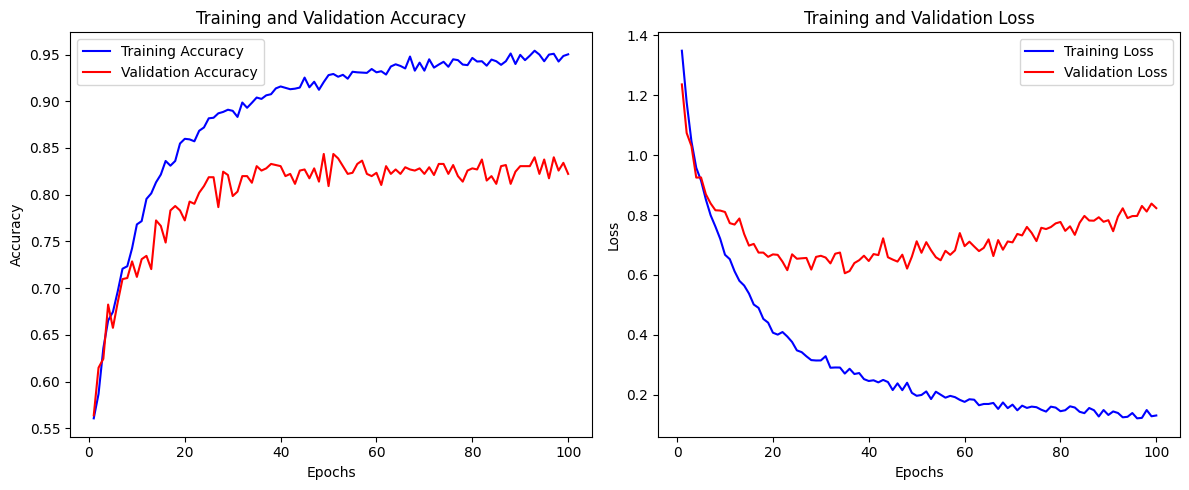

In [14]:
# Plot Training & Validation Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Training & Validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, 'b-', label='Training Loss')
plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Display the plots
plt.tight_layout()
plt.show()